# ARoF MP-DPD - Hyperparameters optimization with Optuna

In [1]:
import sys
from pathlib import Path

file_path    = str(Path.cwd())
project_path = str(Path.cwd().parent.parent)

sys.path.append(project_path)

In [2]:
import optuna
import numpy as np
import matplotlib.pyplot as plt

from functools                import partial
from scipy.signal             import firwin
from tqdm.notebook            import tqdm

from optic.comm.ofdm          import modulateOFDM
from optic.comm.modulation    import modulateGray
from optic.dsp.core           import pnorm, clockSamplingInterp, finddelay
from optic.dsp.coreGPU        import firFilter
from optic.utils              import parameters

from dpd.channel_models       import RoF_channel
from dpd.optuna_tasks         import objective_rof_dpd, get_pareto, get_best_pareto

from optuna.trial             import TrialState
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
font = {'size':14}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - OFDM signal generation

In [4]:
# Parâmetros de modulação
modOrder  = 64                 # Modulation order
constType = 'qam'              # Constellation format
Rb = 5e9                       # Bitrate
SpS = 32

# OFDM parameters
paramOFDM = parameters()
paramOFDM.G   = 32              
paramOFDM.SpS = SpS

paramOFDM.Nfft = 2**10
paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)
paramOFDM.pilotCarriers = np.linspace(0, paramOFDM.Nfft - 1, 32, dtype = np.int64)

Nz = len(paramOFDM.nullCarriers)
Np = len(paramOFDM.pilotCarriers)
Ni = paramOFDM.Nfft - Nz - Np
numOFDMframes = 100

In [5]:
# Bits generation
np.random.seed(2)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(modOrder))))

# Symbols modulation
symbTx = modulateGray(bits, modOrder, constType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [6]:
# OFDM signal generation
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

Rs = Rb / ( Ni / (paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder))
Fs = Rs * paramOFDM.SpS

SpS_DPD = 4
Fs_DPD = Rs * SpS_DPD

t = np.arange(0, sigTx.size)*1/Fs
t_CP   = paramOFDM.SpS * paramOFDM.G * (1/Fs)
t_symb = paramOFDM.SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

### 2 - A-RoF channel

In [ ]:
paramMZM     = paramRoF.paramMZM
    paramRF      = paramRoF.paramRF
    paramFiber   = paramRoF.paramFiber
    paramPD      = paramRoF.paramPD
    paramPA      = paramRoF.paramPA
    
    bw   = paramRF.bw
    Fs   = paramRF.Fs
    fc_e = paramRF.fc_e
    
    # 1 - Generating RF signal
    t = np.arange(0, len(sigTx))*1/Fs
    sigTx_RF = np.real( sigTx * np.exp(1j * 2*pi * fc_e * t) )
    
    gain_pre_MZM = paramMZM.Pin_MZM - 10*np.log10(1e3*signal_power(sigTx_RF))
    
    sigTx_RF = np.sqrt(10**((gain_pre_MZM + gain_DPD)/10)) * sigTx_RF
    sigTx_RF = np.clip(sigTx_RF, -paramMZM.Vpi/2, paramMZM.Vpi/2)
    

    # 2 - Optical modulation with MZM
    Ai     = np.sqrt(dBm2W(paramMZM.P_laser)) * np.ones(sigTx_RF.size)
    sigTxo = mzm(Ai, sigTx_RF, paramMZM)
    
    # 3 - Optical fiber propagation
    hopt_tx = firwin(filter_numtaps, fc_e + 2*bw, fs = Fs)
    sigTxo  = np.sqrt(signal_power(sigTxo)) * pnorm(firFilter(hopt_tx, sigTxo))
    
    sigRxo = linearFiberChannel(sigTxo, paramFiber)
        
    # 4 - Photodetection
    I_Rx = photodiode(sigRxo, paramPD)
    I_Rx -= I_Rx.mean()
    
    # 5 - Bandpass filter and demodulation
    hbp_RF = firwin(filter_numtaps, (fc_e - 2*bw, fc_e + 2*bw), pass_zero = 'bandpass', fs = Fs)
    I_RF = firFilter(hbp_RF, I_Rx)    
    sigRx = hilbert(I_RF)*np.exp(-1j * 2*pi * fc_e * t) * 1e3
    
    # 6 - Power amplifier    
    sigRx = power_amplifier(sigRx, paramPA)
    sigRx = pnorm(sigRx)
    

In [7]:
# MZM parameters
paramMZM = parameters()
paramMZM.Vpi = 3
paramMZM.Vb = -paramMZM.Vpi*0.5
paramMZM.P_laser = 0
paramMZM.Pin_MZM = 17

# RF parameters
paramRF = parameters()
paramRF.fc_e = 3.55e9
paramRF.bw = Rs
paramRF.Fs = Fs

# Optical fiber parameters
paramFiber = parameters()
paramFiber.L = 20
paramFiber.alpha = 0.2
paramFiber.D = 16
paramFiber.Fc = 193.1e12
paramFiber.Fs = Fs

# Photodiode parameters
paramPD = parameters()
paramPD.ideal = False
paramPD.B = paramRF.fc_e + 2*Rs
paramPD.Ipd_sat = 50e-3
paramPD.Fs = Fs

# PA parameters
paramPA = parameters()
paramPA.model_name = "modified_rapp"
paramPA.g = 16
paramPA.x_sat = 1.9
paramPA.sigma_p = 1.1
paramPA.alpha = -345
paramPA.beta = 0.17
paramPA.q = 4

In [8]:
paramRoF = parameters()
paramRoF.paramMZM = paramMZM
paramRoF.paramRF = paramRF
paramRoF.paramFiber = paramFiber
paramRoF.paramPD = paramPD
paramRoF.paramPA = paramPA

sigRx_PA = RoF_channel(sigTx, paramRoF, filter_numtaps = 4096)

hlp = firwin(4096, Rs/1.75, fs = Fs)
sigRx = firFilter(hlp, sigRx_PA)

### 3 - Data for training

In [9]:
hlp = firwin(4096, SpS_DPD*Rs/2, fs = Fs)

sigRef = clockSamplingInterp(pnorm(firFilter(hlp, sigTx).reshape(-1, 1)), Fs, Fs_DPD).ravel()
sigIn  = clockSamplingInterp(pnorm(firFilter(hlp, sigRx_PA).reshape(-1, 1)), Fs, Fs_DPD).ravel()

delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

### 4 - Optuna hyperparameter optimization

In [10]:
M = 2
P = 3

paramModel = parameters()
paramModel.model_name = "MP"
paramModel.M = M
paramModel.P = P

paramTrain = parameters()
paramTrain.epochs = 5
paramTrain.mu  = 1e-3
paramTrain.lbd = 0.9999
paramTrain.S   = np.eye(paramModel.P*(paramModel.M + 1), dtype = complex)*5e-2
paramTrain.alg = "RLS"
paramTrain.pgrsBar = False

data = parameters()
data.sigIn     = sigIn[0:20_000]
data.sigRef    = sigRef[0:20_000]
data.sigTx     = sigTx 
data.Rs        = Rs
data.SpS       = SpS
data.Fs        = Fs
data.Fs_DPD    = Fs_DPD
data.modOrder  = modOrder
data.constType = constType

paramMetrics = parameters()
paramMetrics.bw_for_aclr = Rs/2
paramMetrics.offset_for_aclr = 10e6
paramMetrics.discard = 100
paramMetrics.metrics = ["EVM", "ACLR", "NFLOP"]

In [11]:
study_num = 1
n_trials  = 110
timeout   = 60*60*20

metrics = ["ACLR", "EVM", "NFLOPs"]
sampler = "GridSampler" # TPESampler

search_space = {
    'P': [i for i in range(1, 11)],
    'M': [i for i in range(0, 11)]
}

paramMetrics.model_path = file_path + f"\\study{study_num}\\models"

In [12]:
objective_ILA = partial(objective_rof_dpd, data = data, paramOFDM = paramOFDM, paramRoF = paramRoF, 
                        paramModel = paramModel, paramTrain = paramTrain, paramMetrics = paramMetrics)

if sampler == "GridSampler":
    study_ILA = optuna.create_study(directions=["minimize", "minimize", "minimize"], sampler = optuna.samplers.GridSampler(search_space))

elif sampler == "TPESampler":
    study_ILA = optuna.create_study(directions=["minimize", "minimize", "minimize"], sampler = optuna.samplers.TPESampler())

else:
    print("No sampler")
    
study_ILA.optimize(objective_ILA, n_trials = n_trials, timeout = timeout, show_progress_bar = True)

  0%|          | 0/110 [00:00<?, ?it/s]

In [13]:
description = f"""
sampler: {sampler}
ntrials: {n_trials} 

Hyperparameters range: 
M: 0 - 10
P: 1 - 10

Obs.: EVM, ACLR and NFLOP as objective functions
"""
with open(file_path + f"\\study{study_num}\\description.txt", "w") as description_file:
    description_file.write(description)

In [16]:
complete_trials   = study_ILA.get_trials(deepcopy = False, states = [TrialState.COMPLETE])
n_complete_trials = len(complete_trials)

study_P = np.zeros(n_complete_trials)
study_M = np.zeros(n_complete_trials)

study_EVM    = np.zeros(n_complete_trials)
study_ACLR   = np.zeros(n_complete_trials)
study_NFLOP = np.zeros(n_complete_trials)

for j in range(n_complete_trials):
    trials_params   = complete_trials[j].params
    study_EVM[j]    = complete_trials[j].values[0]
    study_ACLR[j]   = complete_trials[j].values[1]
    study_NFLOP[j] = complete_trials[j].values[2]
    
    study_P[j] = trials_params["P"]
    study_M[j] = trials_params["M"]

np.savetxt(file_path + f'\\study{study_num}\\parameters\\P.txt', study_P, fmt = '%f')
np.savetxt(file_path + f'\\study{study_num}\\parameters\\M.txt', study_M, fmt = '%f')
np.savetxt(file_path + f'\\study{study_num}\\results\\NFLOp.txt', study_NFLOP, fmt = '%f')
np.savetxt(file_path + f'\\study{study_num}\\results\\ACLR.txt', study_ACLR, fmt = '%f')
np.savetxt(file_path + f'\\study{study_num}\\results\\EVM.txt', study_EVM, fmt = '%f')

## EVM vs NFLOP

In [147]:
# EVM vs NFLOPs
pareto_evm, pareto_trials_evm = get_pareto(study_EVM, study_NFLOP, n_trials)
best_evm, best_arg_evm, ideal_evm = get_best_pareto(pareto_evm, weights = (2, 1))

print(f"Best solution: \nTrial = {pareto_trials_evm[best_arg_evm]}, NFLOP = {best_evm[0]:.0f}, EVM = {best_evm[1]:.3f} %\n")

print("-Pareto solutions:")
for i, tt in enumerate(pareto_trials_evm):
    print(f"Trial {tt} \nNFLOP = {study_NFLOP[tt-1]:.1f} \nEVM = {study_EVM[tt-1]:.3f} % \nACLR = {study_ACLR[tt-1]:.3f} dB, \nP = {study_P[tt-1]}, \nM = {study_M[tt-1]}\n")

Best solution: 
Trial = 4, NFLOP = 38, EVM = 3.840 %

-Pareto solutions:
Trial 53 
NFLOP = 71.0 
EVM = 3.451 % 
ACLR = -28.708 dB, 
P = 6.0, 
M = 0.0

Trial 26 
NFLOP = 49.0 
EVM = 3.505 % 
ACLR = -28.912 dB, 
P = 4.0, 
M = 0.0

Trial 4 
NFLOP = 38.0 
EVM = 3.840 % 
ACLR = -28.783 dB, 
P = 3.0, 
M = 0.0

Trial 44 
NFLOP = 27.0 
EVM = 5.193 % 
ACLR = -27.865 dB, 
P = 2.0, 
M = 0.0

Trial 57 
NFLOP = 16.0 
EVM = 10.899 % 
ACLR = -25.205 dB, 
P = 1.0, 
M = 0.0



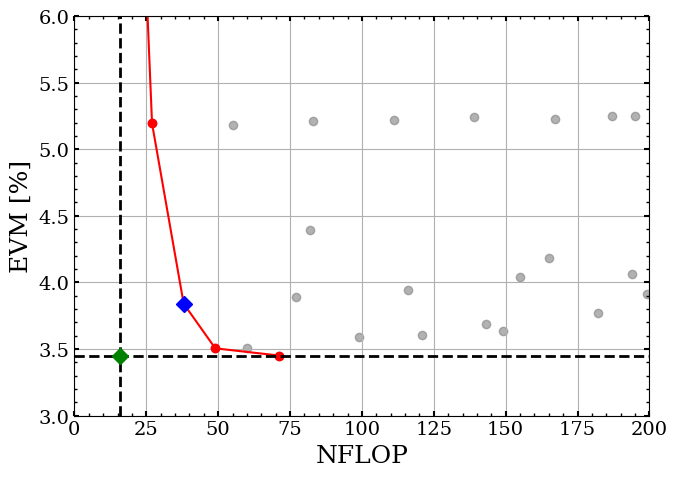

In [148]:
fig, axs = plt.subplots(figsize = (7, 5))

axs.scatter(study_NFLOP, study_EVM, color = "gray", alpha = 0.6)
axs.plot(pareto_evm[:,1], pareto_evm[:,0], "-o", color = "r")

axs.axvline(ideal_evm[0], ls = "--", lw = 2, color = "k")
axs.axhline(ideal_evm[1], ls = "--", lw = 2, color = "k")
axs.plot(ideal_evm[0], ideal_evm[1], "D", ms = 8, color = "g", zorder = 6)

axs.plot(pareto_evm[best_arg_evm, 1], pareto_evm[best_arg_evm, 0], "D", ms = 8, color = "b", zorder = 6)

axs.set_xlim(0, 2e2)
axs.set_ylim(3., 6)
axs.set_xlabel("NFLOP", fontsize = 18)
axs.set_ylabel("EVM [%]", fontsize = 18)

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs.grid()

plt.tight_layout()

## ACLR vs NFLOP

In [149]:
# ACRL vs NFLOPs
pareto_aclr, pareto_trials_aclr = get_pareto(study_ACLR, study_NFLOP, n_trials)
best_aclr, best_arg_aclr, ideal_aclr = get_best_pareto(pareto_aclr, weights = (2, 1))

print(f"Best solution: \nTrial = {pareto_trials_aclr[best_arg_aclr]}, NFLOP = {best_aclr[0]:.0f}, ACLR = {best_aclr[1]:.3f} dB\n")

print("-Pareto solutions:")
for i, tt in enumerate(pareto_trials_aclr):
    print(f"Trial {tt} \nNFLOP = {study_NFLOP[tt-1]:.1f} \nEVM = {study_EVM[tt-1]:.3f} % \nACLR = {study_ACLR[tt-1]:.3f} dB, \nP = {study_P[tt-1]}, \nM = {study_M[tt-1]}\n")

Best solution: 
Trial = 4, NFLOP = 38, ACLR = -28.783 dB

-Pareto solutions:
Trial 5 
NFLOP = 182.0 
EVM = 3.768 % 
ACLR = -29.301 dB, 
P = 5.0, 
M = 2.0

Trial 65 
NFLOP = 149.0 
EVM = 3.635 % 
ACLR = -29.070 dB, 
P = 4.0, 
M = 2.0

Trial 73 
NFLOP = 121.0 
EVM = 3.605 % 
ACLR = -28.946 dB, 
P = 5.0, 
M = 1.0

Trial 26 
NFLOP = 49.0 
EVM = 3.505 % 
ACLR = -28.912 dB, 
P = 4.0, 
M = 0.0

Trial 4 
NFLOP = 38.0 
EVM = 3.840 % 
ACLR = -28.783 dB, 
P = 3.0, 
M = 0.0

Trial 44 
NFLOP = 27.0 
EVM = 5.193 % 
ACLR = -27.865 dB, 
P = 2.0, 
M = 0.0

Trial 57 
NFLOP = 16.0 
EVM = 10.899 % 
ACLR = -25.205 dB, 
P = 1.0, 
M = 0.0



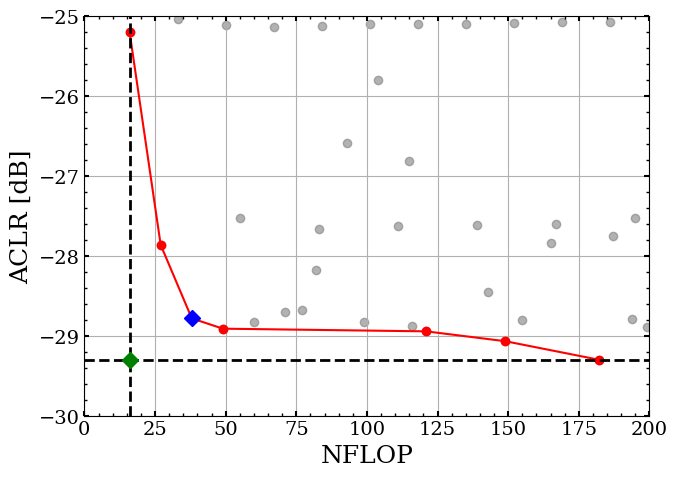

In [150]:
fig, axs = plt.subplots(figsize = (7, 5))

axs.scatter(study_NFLOP, study_ACLR, color = "gray", alpha = 0.6)
axs.plot(pareto_aclr[:,1], pareto_aclr[:,0], "-o", color = "r")

axs.axvline(ideal_aclr[0], ls = "--", lw = 2, color = "k")
axs.axhline(ideal_aclr[1], ls = "--", lw = 2, color = "k")
axs.plot(ideal_aclr[0], ideal_aclr[1], "D", ms = 8, color = "g", zorder = 6)

axs.plot(pareto_aclr[best_arg_aclr, 1], pareto_aclr[best_arg_aclr, 0], "D", ms = 8, color = "b", zorder = 6)

axs.set_xlim(0, 2e2)
axs.set_ylim(-30, -25)
axs.set_xlabel("NFLOP", fontsize = 18)
axs.set_ylabel("ACLR [dB]", fontsize = 18)

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs.grid()

plt.tight_layout()